# U-MobileViT-Net **BASE** — Training & Evaluation on COCO Tea Leaf

**Dataset**: COCO Tea Leaf | 8-class synthetic agricultural disease segmentation
**Model**: U-MobileViT-Net **Base** (d_model=64, ~0.6M parameters)
**Metric**: Mean Intersection over Union (mIoU)
**Input resolution**: 320 x 320 pixels
**Training regime**: Batch size 16, 300 epochs, AdamW, PolyLR scheduler

This notebook trains and evaluates the **base** variant independently.
Checkpoints are saved to `checkpoints/coco_leaf/base/`.


In [1]:
# --- Section 1: Environment and Imports ----------------------------------------


import sys, os
from pathlib import Path

# Locate project root by searching for .git or CLAUDE.md marker
current = Path.cwd()
project_root = current
for parent in [current] + list(current.parents):
    if (parent / ".git").exists() or (parent / "CLAUDE.md").exists():
        project_root = parent
        break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.environ.setdefault("PYTHONPATH", str(project_root))
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True,max_split_size_mb:128,garbage_collection_threshold:0.6")
os.chdir(str(project_root))
print(f"Project root: {project_root}")

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

from models.u_mobilevit_net.u_models import (
    umobilevit, UMobileViT, umobilevit_nano, umobilevit_base,
    umobilevit_pro, umobilevit_promax,
)
from models.u_mobilevit_net.configs import get_variant, UMOBILEVIT_VARIANTS
from tools.data import (
    create_dataloaders, DatasetInfo, label_to_color, denormalize,
)
from tools.training import (
    SegmentationTrainer, TrainingConfig,
    compute_class_weights, compute_pos_weight,
)
from tools.visualization import (
    configure_paper_style, plot_training_curves,
    show_dataset_samples, show_predictions,
    plot_per_class_iou, plot_confusion_matrix,
    plot_error_distribution, plot_params_vs_accuracy,
    plot_convergence_comparison, generate_results_table,
    load_training_history, load_all_results,
    TOL_PALETTE, VARIANT_COLORS,
)
from tools.evaluation import (
    compute_flops, compute_parameters, format_flops,
)

configure_paper_style()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    # print(f"  VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")



Project root: /run/media/sanng/New Volume/Seminar/U-MOBILEVIT-NET
Device: cuda
  GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
# --- Section 2: Configuration ---------------------------------------------------

def configure_experiment():
    return {
        "dataset": "coco_leaf",
        "variant": "base",
        "image_size": (320, 320),
        "batch_size": 16,
        "epochs": 20,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "warmup_epochs": 5,
        "scheduler": "poly",
        "poly_power": 0.9,
        "aug_intensity": "strong",
        "use_class_weights": True,
        "label_smoothing": 0.1,
        "use_ema": True,
        "ema_decay": 0.999,
        "patience": 20,
        "min_epochs": 30,
    }

CFG = configure_experiment()

# Display variant specification
variant_spec = get_variant(CFG["variant"])
print(f"Model variant: {CFG['variant'].upper()}")
print(f"  d_model:             {variant_spec['d_model']}")
print(f"  Transformer blocks:  {variant_spec['num_transformer_blocks']}")
print(f"  Expansion factor:    {variant_spec['expansion_factor']}")
print(f"  Estimated params:    {variant_spec['params_estimate']}")
print()
print("Training configuration:")
for k, v in CFG.items():
    print(f"  {k:<22s} = {v}")


Model variant: BASE
  d_model:             64
  Transformer blocks:  2
  Expansion factor:    3.0
  Estimated params:    ~0.6M

Training configuration:
  dataset                = coco_leaf
  variant                = base
  image_size             = (320, 320)
  batch_size             = 16
  epochs                 = 20
  lr                     = 0.001
  weight_decay           = 0.0001
  warmup_epochs          = 5
  scheduler              = poly
  poly_power             = 0.9
  aug_intensity          = minimal
  use_class_weights      = True
  label_smoothing        = 0.1
  use_ema                = True
  ema_decay              = 0.999
  patience               = 20
  min_epochs             = 30


In [3]:
# --- Section 3: Data Loading ----------------------------------------------------

def load_dataset(config):
    train_loader, val_loader, info = create_dataloaders(
        config["dataset"],
        image_size=config["image_size"],
        batch_size=config["batch_size"],
        num_workers=8,
        aug_intensity=config["aug_intensity"],
    )
    print(f"\nDataset: {info.name}")
    print(f"  Classes:       {info.num_classes} ({info.type})")
    print(f"  Class names:   {', '.join(info.class_names)}")
    print(f"  Training:      {info.train_size:,} images")
    print(f"  Validation:    {info.val_size:,} images")
    print(f"  Input size:    {info.image_size}")
    print(f"  Ignore index:  {info.ignore_index}")
    return train_loader, val_loader, info

train_loader, val_loader, info = load_dataset(CFG)



Dataset: COCO Tea Leaf
  Classes:       8 (multi-class)
  Class names:   healthy_leaf, brown_blight, red_spider_mite, red_rust, gray_blight, helopeltis, green_mirid_bug, tea_algal_leaf_spot
  Training:      8,038 images
  Validation:    1,962 images
  Input size:    (320, 320)
  Ignore index:  255


In [4]:
# --- Section 4: Model Initialisation -------------------------------------------

def build_model(info, variant="base"):
    factory = {
        "nano": umobilevit_nano,
        "base": umobilevit_base,
        "pro": umobilevit_pro,
        "promax": umobilevit_promax,
    }
    model = factory[variant](out_channels=info.num_classes, head="single")
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nModel: U-MobileViT-Net [{variant.upper()}]")
    print(f"  Parameters: {n_params:,} ({n_params / 1e6:.2f} M)")

    # Smoke test: verify output shape
    model.eval()
    with torch.no_grad():
        dummy = torch.randn(2, 3, *info.image_size)
        out = model(dummy)
        expected = (2, info.num_classes, *info.image_size)
        assert out.shape == expected, f"Shape mismatch: {tuple(out.shape)} vs {expected}"
        print(f"  Smoke test:  {tuple(dummy.shape)} -> {tuple(out.shape)}  PASSED")
    return model, n_params

model, n_params = build_model(info, CFG["variant"])

# NaN weight check
model = model.to(device)
nan_params = [n for n, p in model.named_parameters() if not torch.isfinite(p).all()]
if nan_params:
    raise RuntimeError(f"{len(nan_params)} parameters contain NaN/Inf: {nan_params[:5]}")
print("  Weight check: all parameters finite")



Model: U-MobileViT-Net [BASE]
  Parameters: 584,080 (0.58 M)
  Smoke test:  (2, 3, 320, 320) -> (2, 8, 320, 320)  PASSED
  Weight check: all parameters finite


Training samples:


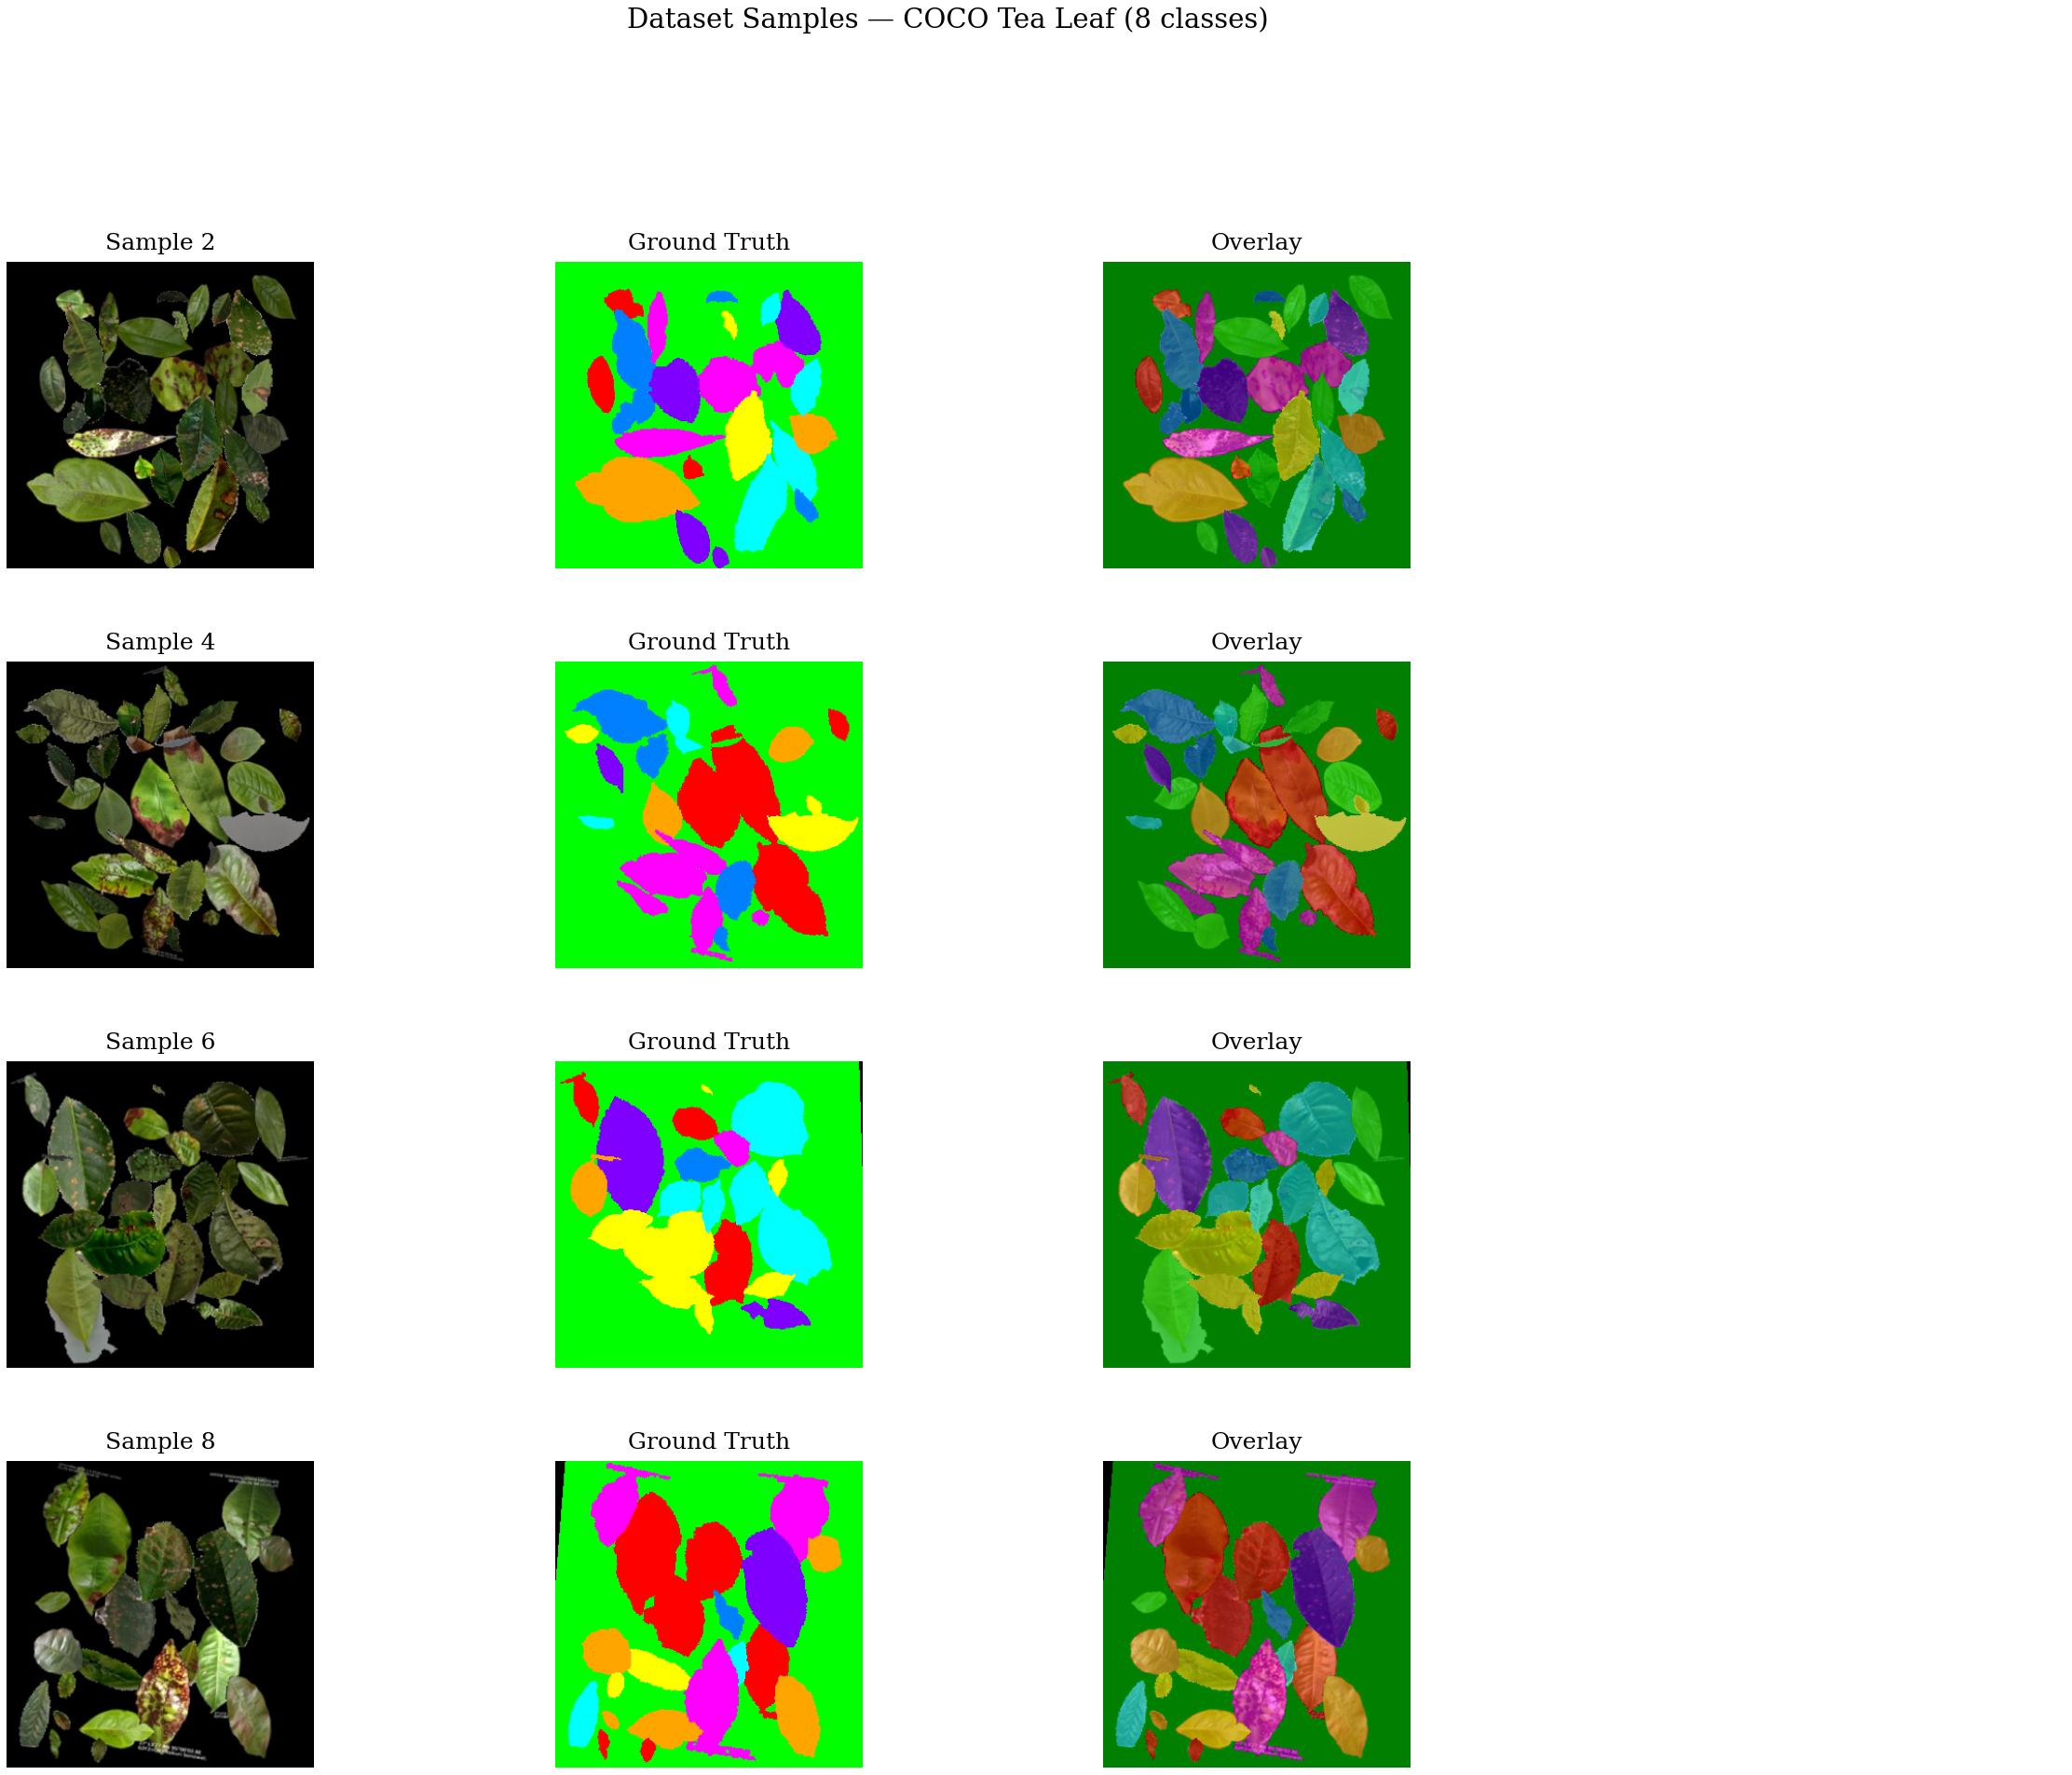

Validation samples:


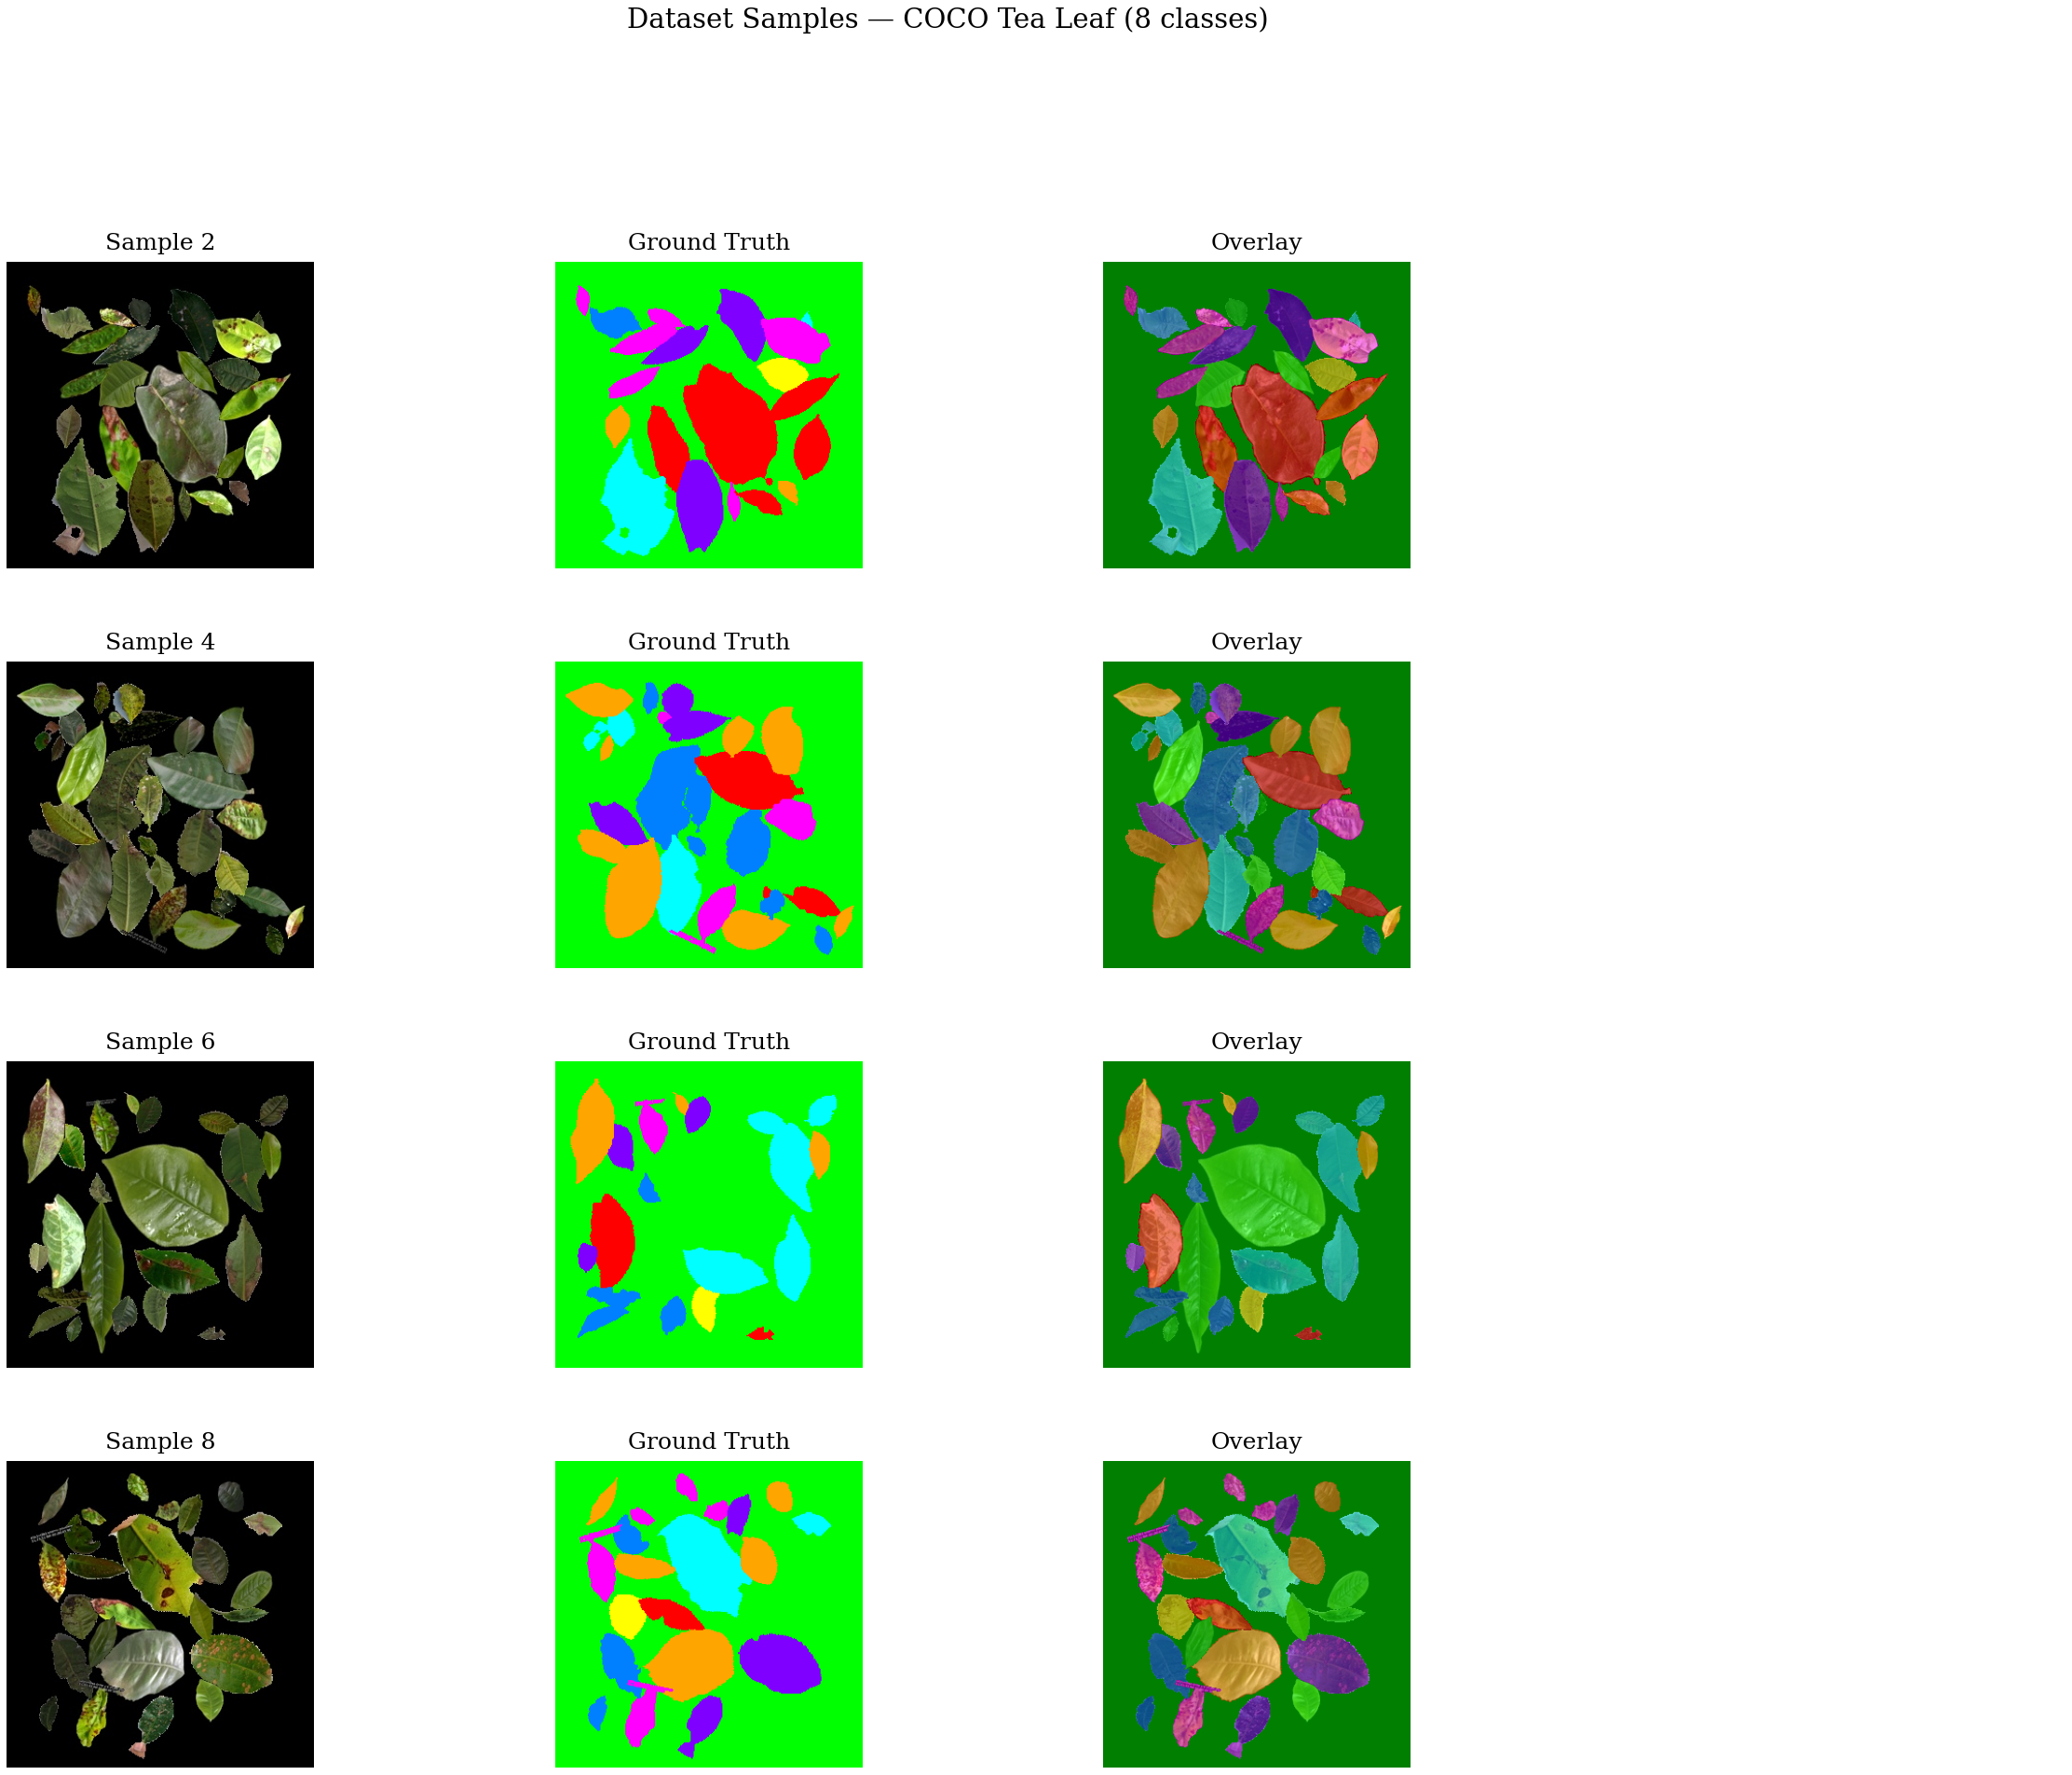

In [5]:
# --- Section 5: Data Visualisation ----------------------------------------------

def visualise_data_samples(train_loader, val_loader, info):
    os.makedirs("paper_figures", exist_ok=True)
    print("Training samples:")
    show_dataset_samples(
        train_loader, info, num_samples=8,
        save_path="paper_figures/01_base_train_samples.pdf",
    )
    print("Validation samples:")
    show_dataset_samples(
        val_loader, info, num_samples=8,
        save_path="paper_figures/01_base_val_samples.pdf",
    )

visualise_data_samples(train_loader, val_loader, info)


In [6]:
# --- Section 6: Training Setup ---------------------------------------------------

def configure_trainer(model, device, info, config, train_loader):
    import os
    save_dir = f"./checkpoints/{config['dataset']}/{config['variant']}"
    os.makedirs(save_dir, exist_ok=True)

    class_weights = None
    pos_weight = None
    if config["use_class_weights"] and info.type == "multi-class":
        print("\nComputing class weights from training data ...")
        class_weights = compute_class_weights(
            train_loader, info.num_classes,
            ignore_index=info.ignore_index, device=device,
        )
    elif info.type == "binary":
        pos_weight = compute_pos_weight(train_loader, device=device)

    training_cfg = TrainingConfig(
        lr=config["lr"],
        weight_decay=config["weight_decay"],
        warmup_epochs=config["warmup_epochs"],
        scheduler_type=config["scheduler"],
        poly_power=config.get("poly_power", 0.9),
        use_ema=config["use_ema"],
        ema_decay=config["ema_decay"],
        label_smoothing=config.get("label_smoothing", 0.0),
        use_checkpointing=True,
        nan_recovery=True,
    )

    trainer = SegmentationTrainer(
        model=model,
        device=device,
        dataset_info=info,
        save_dir=save_dir,
        config=training_cfg,
        class_weights=class_weights,
        pos_weight=pos_weight,
    )

    metric = "Dice" if info.type == "binary" else "mIoU"
    print(f"\nTraining configuration:")
    print(f"  Loss:        {trainer.criterion.__class__.__name__}")
    print(f"  Optimiser:   AdamW (lr={config['lr']}, wd={config['weight_decay']})")
    print(f"  Scheduler:   {config['scheduler'].upper()} + Warmup ({config['warmup_epochs']} ep)")
    print(f"  Metric:      {metric}")
    print(f"  EMA:         {'enabled' if config['use_ema'] else 'disabled'}")
    print(f"  Checkpoint:  {save_dir}")
    return trainer

trainer = configure_trainer(model, device, info, CFG, train_loader)



Computing class weights from training data ...
[Class Weights] Scanning training set for class frequencies ...


KeyboardInterrupt: 

In [ ]:
# --- Section 7: Training ---------------------------------------------------------

def run_training(trainer, train_loader, val_loader, config):
    import time
    t_start = time.time()

    history = trainer.train(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=config["epochs"],
        patience=config["patience"],
        min_epochs=config["min_epochs"],
        save_prefix="best",
    )

    elapsed = time.time() - t_start
    hours, rem = divmod(elapsed, 3600)
    minutes, seconds = divmod(rem, 60)
    print(f"\nTotal training time: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")
    return history

history = run_training(trainer, train_loader, val_loader, CFG)


/home/sanng/miniconda3/envs/vision_env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:216: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
Epoch 1/20 [Train]:   0%|          | 0/502 [00:00<?, ?batch/s]

In [ ]:
# --- Section 8: Training Curves --------------------------------------------------

def plot_results(history, info, config, trainer):
    metric_name = "Dice" if info.type == "binary" else "mIoU"
    best_epoch = trainer.best_epoch
    best_metric = max(history["val_metric"])
    best_loss = min(history["val_loss"])

    print(f"\nBest validation {metric_name}: {best_metric:.4f} (epoch {best_epoch})")
    print(f"Best validation loss:       {best_loss:.4f}")

    os.makedirs("paper_figures", exist_ok=True)
    plot_training_curves(
        history, metric_name=metric_name,
        save_path=f"paper_figures/01_base_training_curves_{config['dataset']}.pdf",
    )

plot_results(history, info, CFG, trainer)


In [ ]:
# --- Section 9: Predictions -----------------------------------------------------

def show_val_predictions(model, val_loader, device, info, trainer):
    import os
    best_path = os.path.join(trainer.save_dir, "best_model.pth")
    if os.path.exists(best_path):
        ckpt = torch.load(best_path, map_location=device, weights_only=True)
        model.load_state_dict(ckpt["model_state_dict"])
        print(f"\nLoaded best checkpoint from epoch {ckpt['epoch']}")
    else:
        print("\nNo best checkpoint found; using current model weights.")

    model.to(device)
    os.makedirs("paper_figures", exist_ok=True)
    show_predictions(
        model, val_loader, device, info, num_samples=8,
        save_path="paper_figures/01_base_predictions.pdf",
    )

show_val_predictions(model, val_loader, device, info, trainer)


In [ ]:
# --- Section 10: Comprehensive Analysis -----------------------------------------

def run_full_analysis(model, val_loader, device, info):
    import numpy as np
    from tqdm import tqdm

    model.eval()
    num_classes = info.num_classes
    ignore_index = info.ignore_index
    class_names = info.class_names

    intersection = torch.zeros(num_classes, device=device)
    union = torch.zeros(num_classes, device=device)
    confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    all_targets = []

    for images, masks in tqdm(val_loader, desc="[Analysis]", unit="batch", leave=False):
        images_gpu = images.to(device)
        with torch.no_grad():
            outputs = model(images_gpu)  # [FP32] Không dùng autocast
        preds = outputs.argmax(dim=1).cpu()
        preds_dev = preds.to(device)
        masks_dev = masks.to(device)
        valid = (masks_dev != ignore_index)

        for c in range(num_classes):
            t_c = (masks_dev == c)
            p_c = (preds_dev == c) & valid
            intersection[c] += (p_c & t_c).float().sum()
            union[c] += (p_c | t_c).float().sum()

        valid_flat = (masks_dev != ignore_index)
        for c in range(num_classes):
            t_c = (masks_dev == c) & valid_flat
            if t_c.sum() == 0:
                continue
            pred_flat = preds_dev[valid_flat]
            confusion[c] += torch.bincount(
                pred_flat[t_c[valid_flat]], minlength=num_classes,
            ).cpu()

        all_targets.append(masks)

    # Per-class IoU
    per_class_iou = []
    for c in range(num_classes):
        iou_c = (intersection[c].item() + 1e-6) / (union[c].item() + 1e-6)
        per_class_iou.append(min(iou_c, 1.0))
    mean_iou = np.mean(per_class_iou)

    print(f"\nMean IoU: {mean_iou:.4f}")
    print(f"\n{'Class':<30s} {'IoU':>8s}  {'Status':>8s}")
    print("-" * 52)
    for c in range(num_classes):
        status = "GOOD" if per_class_iou[c] >= 0.7 else ("OK" if per_class_iou[c] >= 0.5 else "LOW")
        print(f"  {class_names[c]:<28s} {per_class_iou[c]:>6.4f}  {status:>8s}")

    # Confusion matrix normalised
    cm_np = confusion.numpy()
    cm_norm = cm_np.astype(np.float64)
    for c in range(num_classes):
        row_sum = cm_norm[c].sum()
        if row_sum > 0:
            cm_norm[c] /= row_sum

    # Pixel distribution
    all_targets = torch.cat(all_targets).numpy()
    total_pixels = (all_targets != ignore_index).sum()
    print(f"\nPixel distribution:")
    for c in range(num_classes):
        cnt = (all_targets == c).sum()
        print(f"  {class_names[c]:<28s} {cnt:>10,}  ({cnt/total_pixels*100:>5.1f}%)")

    os.makedirs("paper_figures", exist_ok=True)

    plot_per_class_iou(
        class_names, per_class_iou,
        save_path="paper_figures/01_base_per_class_iou.pdf",
    )
    plot_confusion_matrix(
        cm_np, cm_norm, class_names,
        save_path="paper_figures/01_base_confusion_matrix.pdf",
    )

    return {"per_class_iou": per_class_iou, "mean_iou": mean_iou,
            "confusion": cm_np, "confusion_norm": cm_norm}

analysis = run_full_analysis(model, val_loader, device, info)


In [ ]:
# --- Section 11: Summary ---------------------------------------------------------

def print_summary(config, n_params, info, history, analysis, trainer):
    metric_name = "Dice" if info.type == "binary" else "mIoU"
    best_epoch = trainer.best_epoch
    best_metric = max(history["val_metric"])
    best_loss = min(history["val_loss"])

    print("=" * 72)
    print("  EXPERIMENT SUMMARY | U-MobileViT-Net BASE")
    print("=" * 72)
    print(f"  Dataset:           {info.name}")
    print(f"  Model variant:     {config['variant'].upper()}")
    print(f"  Parameters:        {n_params:,} ({n_params/1e6:.2f} M)")
    print(f"  Input resolution:  {config['image_size']}")
    print(f"  Classes:           {info.num_classes} ({info.type})")
    print(f"  Training samples:  {info.train_size:,}")
    print(f"  Validation samples:{info.val_size:,}")
    print(f"  Augmentation:      {config['aug_intensity']}")
    print(f"  Optimiser:         AdamW (lr={config['lr']}, wd={config['weight_decay']})")
    print(f"  Scheduler:         {config['scheduler'].upper()} + Warmup ({config['warmup_epochs']} ep)")
    print(f"  EMA:               {'enabled' if config['use_ema'] else 'disabled'}")
    print(f"  Label smoothing:   {config.get('label_smoothing', 0.0)}")
    print(f"  Class weights:     {config.get('use_class_weights', False)}")
    print(f"  Best epoch:        {best_epoch}")
    print(f"  Best {metric_name}:          {best_metric:.4f}")
    print(f"  Mean per-class IoU:{analysis['mean_iou']:.4f}")
    print(f"  Best val loss:     {best_loss:.4f}")
    print(f"  Checkpoint:        {trainer.save_dir}")
    print("=" * 72)

print_summary(CFG, n_params, info, history, analysis, trainer)
